<a href="https://colab.research.google.com/github/Arjunanand717/Deep-learing-/blob/main/EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Roll Number: 24BAD401
NAME:ARJUN S

## PART A: Dataset Preparation

We will use the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1599s 9us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


### Preprocessing Images

We will normalize the pixel values from the range of 0-255 to 0-1 and convert the class labels to a one-hot encoded format.

In [2]:
# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)

print(f'x_train_normalized shape: {x_train_normalized.shape}')
print(f'y_train_one_hot shape: {y_train_one_hot.shape}')
print(f'x_test_normalized shape: {x_test_normalized.shape}')
print(f'y_test_one_hot shape: {y_test_one_hot.shape}')

x_train_normalized shape: (50000, 32, 32, 3)
y_train_one_hot shape: (50000, 10)
x_test_normalized shape: (10000, 32, 32, 3)
y_test_one_hot shape: (10000, 10)


### Splitting the Dataset into Training, Validation, and Testing Sets

We already have a test set. Now we will further split the existing training data into training and validation sets. A common split is 80% for training and 20% for validation from the original training set.

In [3]:
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets
x_train_final, x_val_final, y_train_final, y_val_final = train_test_split(
    x_train_normalized, y_train_one_hot, test_size=0.2, random_state=42
)

print(f'Final x_train shape: {x_train_final.shape}')
print(f'Final y_train shape: {y_train_final.shape}')
print(f'x_val shape: {x_val_final.shape}')
print(f'y_val shape: {y_val_final.shape}')
print(f'x_test shape: {x_test_normalized.shape}')
print(f'y_test shape: {y_test_one_hot.shape}')

Final x_train shape: (40000, 32, 32, 3)
Final y_train shape: (40000, 10)
x_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


## PART B: CNN Model Design and Implementation

In this section, we will design and implement a Convolutional Neural Network (CNN) for image classification. We will use TensorFlow/Keras to build the model.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=x_train_final.shape[1:]),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Add dropout for regularization
    Dense(num_classes, activation='softmax') # Output layer with softmax for classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

## PART C: Train and Evaluate the CNN Model

Now we will train the CNN model using our prepared training and validation datasets. We will also monitor the training process and evaluate the model's performance.

In [6]:
history = model.fit(
    x_train_final, y_train_final,
    epochs=4, # Number of training epochs
    batch_size=64, # Number of samples per gradient update
    validation_data=(x_val_final, y_val_final), # Data on which to evaluate the loss and any model metrics at the end of each epoch
    verbose=1 # Progress bar will be shown for each epoch
)

print("Model training complete.")

Epoch 1/4
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6277 - loss: 1.0676 - val_accuracy: 0.6516 - val_loss: 0.9868
Epoch 2/4
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.6555 - loss: 0.9886 - val_accuracy: 0.6658 - val_loss: 0.9607
Epoch 3/4
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.6747 - loss: 0.9360 - val_accuracy: 0.6726 - val_loss: 0.9441
Epoch 4/4
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 92ms/step - accuracy: 0.6913 - loss: 0.8826 - val_accuracy: 0.6821 - val_loss: 0.9239
Model training complete.


### Visualize Training and Validation Performance

We will plot the training and validation accuracy and loss over the epochs to understand the model's learning process and identify potential overfitting or underfitting.

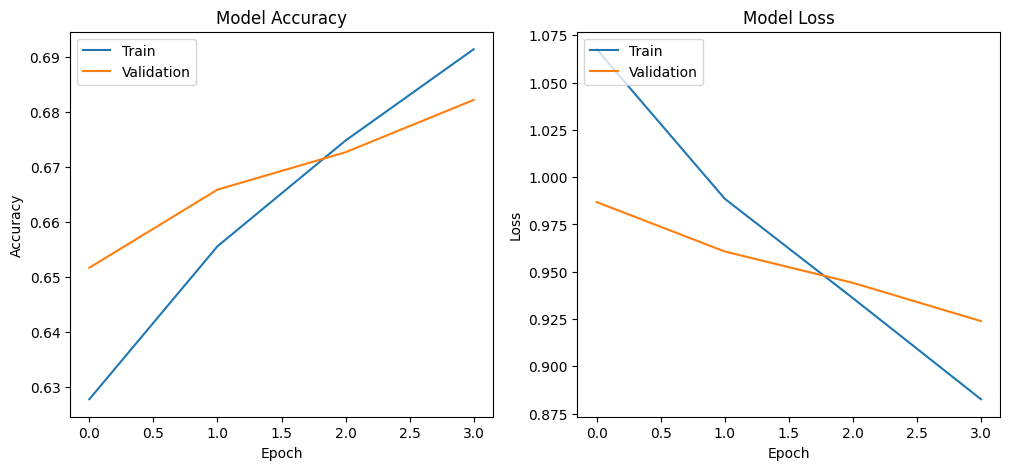

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluate Model on Test Data

Finally, we will evaluate the trained model on the independent test dataset to assess its generalization capability.

In [8]:
test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=2)
print(f'Test accuracy: {test_accuracy*100:.2f}%')
print(f'Test loss: {test_loss:.4f}')

313/313 - 4s - 12ms/step - accuracy: 0.6694 - loss: 0.9418
Test accuracy: 66.94%
Test loss: 0.9418


## PART D: Performance Analysis

In this section, we will analyze the performance of our trained CNN model in more detail. This includes generating a confusion matrix, visualizing sample predictions, and identifying misclassified images.

### Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm. We will calculate the confusion matrix and display it as a heatmap.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


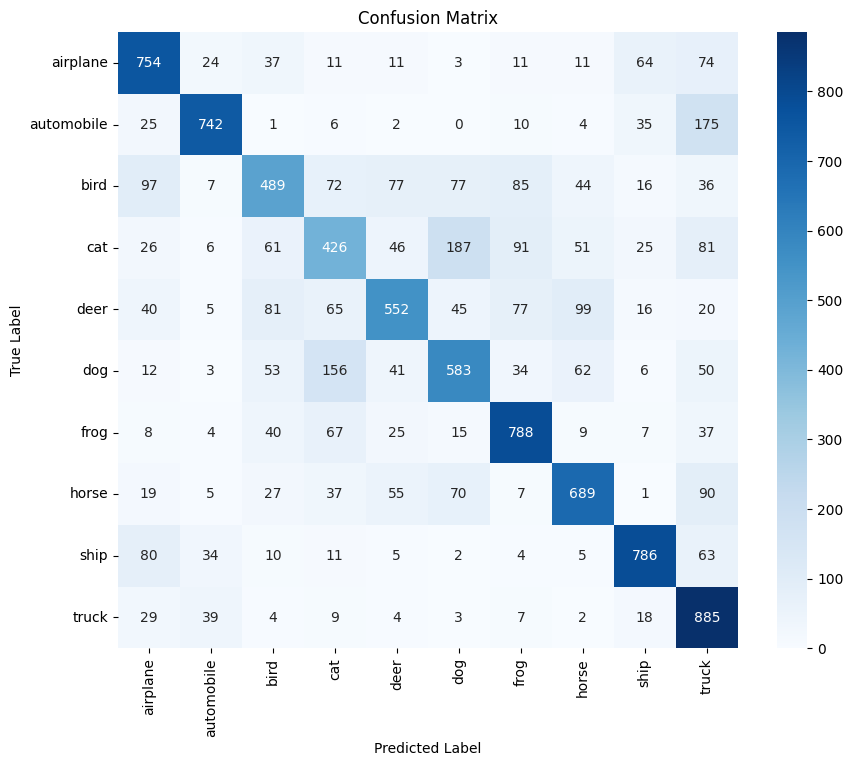

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the test set
y_pred_one_hot = model.predict(x_test_normalized)
y_pred = np.argmax(y_pred_one_hot, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()